# Diagnóstico Estatístico da Série Temporal

## 1. Objetivo do Notebook

No notebook anterior, analisamos a evolução da carga por ano, mês, dia da semana, horário e subsistema.

Agora, vamos trabalhar com a série diária do Sistema Interligado Nacional para entender melhor suas características ao longo do tempo.

Nesta etapa, vamos verificar:

- se a sequência diária está completa;
- como a média e a variação mudam durante o período;
- se a série possui tendência e ciclos semanal e anual;
- quanto um dia está relacionado com os dias anteriores;
- se a série é estacionária;
- se ainda existe algum padrão depois da decomposição.

Não serão criados modelos de previsão ou de Machine Learning. Assim como nos outros notebooks, cada conclusão será feita somente depois da sua verificação em código.

## 2. Importação das Bibliotecas e Carregamento dos Dados


In [1]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option('display.max_columns', None)

DATA_PATH = Path('../data/processed')

In [2]:
electric_data = pd.read_parquet(
    DATA_PATH / 'curva_carga_consolidado.parquet'
)

electric_data.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiahomwmed
0,N,NORTE,2000-01-01 00:00:00,2373.7
1,NE,NORDESTE,2000-01-01 00:00:00,5340.2
2,S,SUL,2000-01-01 00:00:00,5777.0
3,SE,SUDESTE,2000-01-01 00:00:00,21183.0
4,N,NORTE,2000-01-01 01:00:00,2331.6


In [3]:
electric_data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911608 entries, 0 to 911607
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   id_subsistema            911608 non-null  object        
 1   nom_subsistema           911608 non-null  object        
 2   din_instante             911608 non-null  datetime64[ns]
 3   val_cargaenergiahomwmed  911348 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 105.4 MB


In [4]:
print(f'Quantidade de registros: {electric_data.shape[0]:,}')
print(f'Data inicial: {electric_data["din_instante"].min()}')
print(f'Data final: {electric_data["din_instante"].max()}')

Quantidade de registros: 911,608
Data inicial: 2000-01-01 00:00:00
Data final: 2025-12-31 23:00:00


O arquivo carregado possui 911.608 registros e quatro colunas.

A data está no formato datetime64 e a carga está como float64, seguindo o tratamento realizado na consolidação.

O período começa em 01/01/2000 às 00:00 e termina em 31/12/2025 às 23:00.

Com essas informações confirmadas, podemos montar a série do SIN.

## 3. Construção da Série Diária do SIN

Primeiro, vamos reorganizar os dados para que cada linha represente um horário e cada coluna represente um subsistema.

A carga do SIN será calculada somente quando os quatro subsistemas possuírem valores válidos naquele horário.


In [5]:
hourly_load = electric_data.pivot(
    index='din_instante',
    columns='id_subsistema',
    values='val_cargaenergiahomwmed'
)

hourly_load.head()

id_subsistema,N,NE,S,SE
din_instante,,,,
2000-01-01 00:00:00,2373.7,5340.2,5777.0,21183.0
2000-01-01 01:00:00,2331.6,5180.8,5580.7,20409.9
2000-01-01 02:00:00,2332.9,5068.6,5098.7,19787.4
2000-01-01 03:00:00,2311.6,4905.1,4753.7,19089.0
2000-01-01 04:00:00,2287.8,4811.7,4584.1,18589.1


In [6]:
hourly_load['carga_sin'] = hourly_load[
    ['N', 'NE', 'S', 'SE']
].sum(axis=1, min_count=4)

print(f'Horários presentes na tabela: {hourly_load.shape[0]:,}')
print(f'Horários com carga válida: {hourly_load["carga_sin"].notna().sum():,}')
print(f'Horários sem carga válida: {hourly_load["carga_sin"].isna().sum():,}')

Horários presentes na tabela: 227,914
Horários com carga válida: 227,837
Horários sem carga válida: 77


A reorganização gerou 227.914 horários presentes na base.

Desses horários, 227.837 possuem as quatro cargas necessárias para calcular o SIN. Os outros 77 continuam sem carga total.

Esses casos já foram analisados no notebook exploratório. Agora, vamos verificar como eles aparecem depois que os dados são transformados em uma série diária.


In [7]:
daily_load = hourly_load['carga_sin'].resample('D').mean()

daily_load.head()

din_instante
2000-01-01    30736.529167
2000-01-02    31453.354167
2000-01-03    37466.737500
2000-01-04    39149.970833
2000-01-05    39961.879167
Freq: D, Name: carga_sin, dtype: float64

In [8]:
print(f'Dias na sequência temporal: {daily_load.shape[0]:,}')
print(f'Data inicial: {daily_load.index.min()}')
print(f'Data final: {daily_load.index.max()}')
print(f'Dias sem carga média: {daily_load.isna().sum()}')

Dias na sequência temporal: 9,497
Data inicial: 2000-01-01 00:00:00
Data final: 2025-12-31 00:00:00
Dias sem carga média: 3


A agregação criou uma sequência com 9.497 dias entre 2000 e 2025.

O resultado também mostrou três dias sem carga média. Antes de fazer qualquer preenchimento, vamos localizar essas datas.


In [9]:
daily_load[daily_load.isna()]

din_instante
2013-12-01   NaN
2014-02-01   NaN
2015-04-09   NaN
Name: carga_sin, dtype: float64

Os três dias sem carga são 01/12/2013, 01/02/2014 e 09/04/2015.

São as mesmas datas que apresentaram 24 horas sem carga total na análise anterior.

Agora, vamos verificar se existem outros dias cuja média foi calculada com menos de 24 horas válidas.


In [10]:
valid_hours_by_day = hourly_load['carga_sin'].resample('D').count()

valid_hours_by_day.value_counts().sort_index()

carga_sin
0        3
23      19
24    9475
Name: count, dtype: int64

In [11]:
valid_hours_by_day[valid_hours_by_day < 24]

din_instante
2000-10-08    23
2001-10-14    23
2002-11-03    23
2003-10-19    23
2004-11-02    23
2005-10-16    23
2006-11-05    23
2007-10-14    23
2008-10-19    23
2009-10-18    23
2010-10-17    23
2011-10-16    23
2012-10-21    23
2013-10-20    23
2013-12-01     0
2014-02-01     0
2014-10-19    23
2015-04-09     0
2015-10-18    23
2016-10-16    23
2017-10-15    23
2018-11-04    23
Name: carga_sin, dtype: int64

A contagem mostrou três situações:

- 9.475 dias possuem 24 horas válidas;
- 19 dias possuem 23 horas válidas;
- 3 dias não possuem nenhuma hora válida.

Os dias com 23 horas são as datas de início do horário de verão que já foram verificadas. Como eles possuem praticamente todas as observações e realmente tiveram uma duração diferente, suas médias serão mantidas.

Já os três dias completamente vazios precisam ser preenchidos para que a série fique regular e possa ser decomposta.

Antes de escolher o tratamento, vamos comparar duas opções: a interpolação entre o dia anterior e o seguinte e a média do mesmo dia da semana anterior e posterior.


In [12]:
missing_days = daily_load.index[daily_load.isna()]
linear_interpolation = daily_load.interpolate(method='time')

gap_comparison = []

for day in missing_days:

    previous_week = daily_load.loc[day - pd.Timedelta(days=7)]
    next_week = daily_load.loc[day + pd.Timedelta(days=7)]

    gap_comparison.append({
        'data': day,
        'dia_semana': day.day_name(),
        'dia_anterior': daily_load.loc[day - pd.Timedelta(days=1)],
        'dia_posterior': daily_load.loc[day + pd.Timedelta(days=1)],
        'mesmo_dia_semana_anterior': previous_week,
        'mesmo_dia_semana_posterior': next_week,
        'interpolacao_linear': linear_interpolation.loc[day],
        'media_mesmo_dia_semana': (previous_week + next_week) / 2
    })

gap_comparison = pd.DataFrame(gap_comparison).set_index('data')

gap_comparison.round(2)

,dia_semana,dia_anterior,dia_posterior,mesmo_dia_semana_anterior,mesmo_dia_semana_posterior,interpolacao_linear,media_mesmo_dia_semana
data,,,,,,,
2013-12-01,Sunday,59305.83,63138.35,51549.37,53797.76,61222.09,52673.57
2014-02-01,Saturday,71668.09,58893.35,62884.96,66805.90,65280.72,64845.43
2015-04-09,Thursday,64498.35,64861.16,65312.25,66370.41,64679.76,65841.33


Os dois métodos ficaram próximos em 01/02/2014 e 09/04/2015. A maior diferença apareceu em 01/12/2013.

Essa data foi um domingo. A interpolação entre sábado e segunda-feira estimou 61.222,09 MWmed. A média entre o domingo anterior e o domingo seguinte estimou 52.673,57 MWmed.

Como a análise exploratória mostrou que o domingo possui uma carga diferente dos outros dias, vamos utilizar a média dos domingos vizinhos. Dessa forma, o ciclo semanal será melhor preservado.

Esses valores servem apenas para completar a sequência. Eles são estimativas e não representam a carga real que ocorreu nas datas ausentes.


In [13]:
daily_series = daily_load.copy()

for day in missing_days:

    daily_series.loc[day] = (
        daily_load.loc[day - pd.Timedelta(days=7)]
        + daily_load.loc[day + pd.Timedelta(days=7)]
    ) / 2

print(f'Frequência identificada: {pd.infer_freq(daily_series.index)}')
print(f'Dias na série: {daily_series.shape[0]:,}')
print(f'Valores ausentes: {daily_series.isna().sum()}')

Frequência identificada: D
Dias na série: 9,497
Valores ausentes: 0


Depois do preenchimento, a série possui frequência diária, 9.497 observações e nenhum valor ausente.

Somente os três dias completamente vazios foram estimados. Os 19 dias com 23 horas continuaram com suas médias originais.

## 4. Estabilidade da Média e da Variabilidade

Uma série estacionária mantém características como média e variância relativamente estáveis ao longo do tempo.

Antes dos testes estatísticos, vamos observar a média e o desvio-padrão em janelas móveis de 365 dias. Essa janela reduz as oscilações de curto prazo e facilita a visualização das mudanças mais lentas.


In [14]:
rolling_statistics = pd.DataFrame({
    'media_movel': daily_series.rolling(365).mean(),
    'desvio_movel': daily_series.rolling(365).std()
})

rolling_statistics['cv_%'] = (
    rolling_statistics['desvio_movel']
    / rolling_statistics['media_movel']
    * 100
)

rolling_statistics.dropna().head()

,media_movel,desvio_movel,cv_%
din_instante,,,
2000-12-30,40827.053581,3228.115982,7.906806
2000-12-31,40839.387918,3197.914740,7.830467
2001-01-01,40841.069564,3193.123265,7.818412
2001-01-02,40847.625499,3188.629586,7.806157
2001-01-03,40855.879485,3188.122274,7.803338


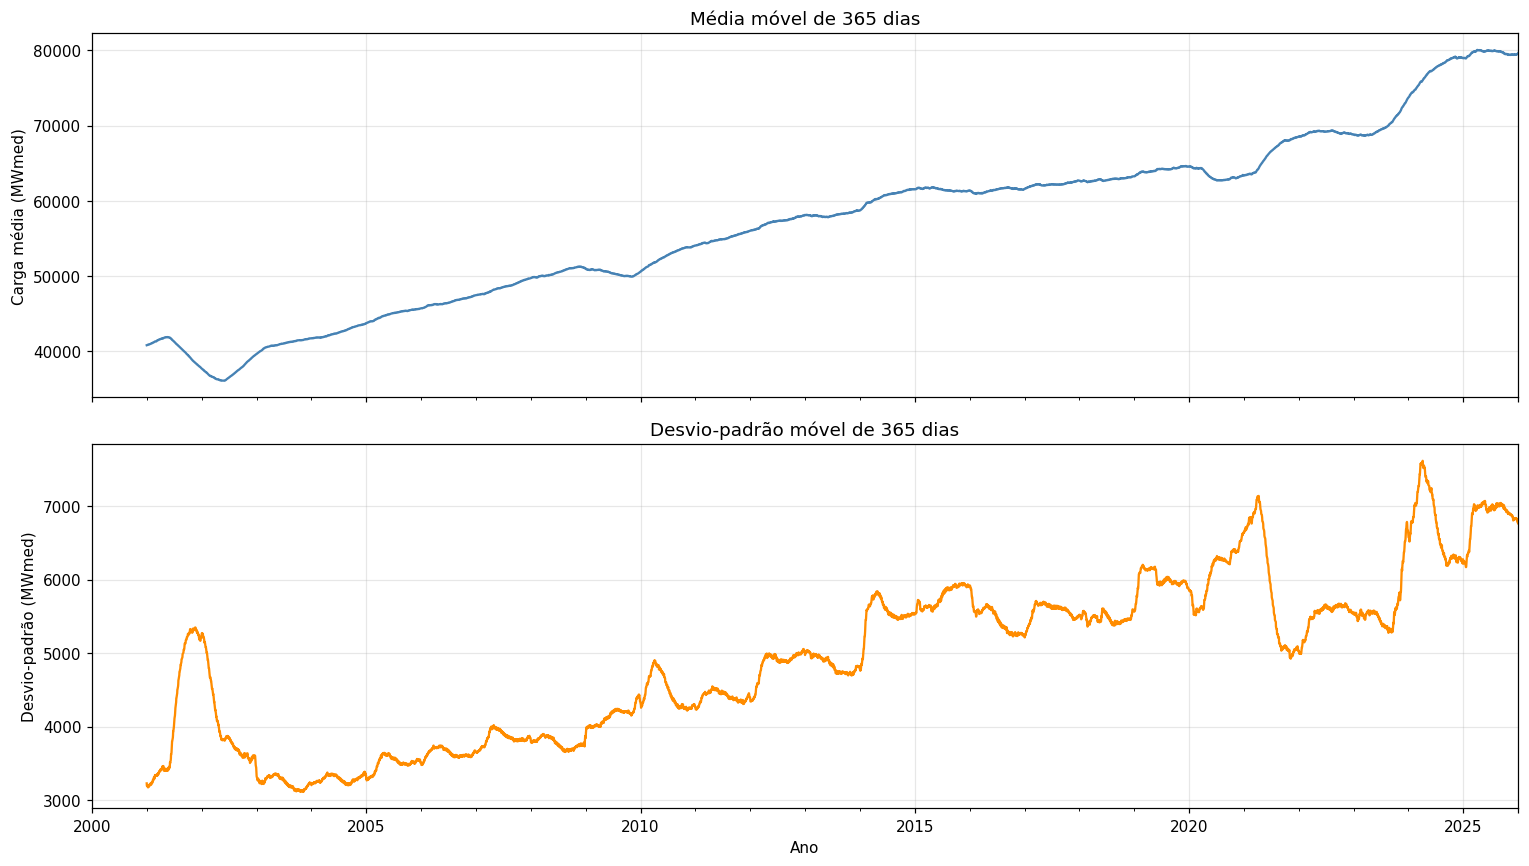

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

rolling_statistics['media_movel'].plot(
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Média móvel de 365 dias')
axes[0].set_ylabel('Carga média (MWmed)')
axes[0].grid(alpha=0.3)

rolling_statistics['desvio_movel'].plot(
    ax=axes[1],
    color='darkorange'
)
axes[1].set_title('Desvio-padrão móvel de 365 dias')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Desvio-padrão (MWmed)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

A média móvel não permanece no mesmo nível. Ela cresce durante o período e também apresenta momentos de queda e estabilidade.

O desvio-padrão móvel também muda ao longo da série. Em alguns períodos, a carga média mais alta vem acompanhada de uma variação maior em MWmed.

Para medir essa relação, vamos calcular a correlação entre a média móvel e o desvio-padrão móvel.


In [16]:
rolling_statistics[
    ['media_movel', 'desvio_movel']
].corr().round(3)

,media_movel,desvio_movel
media_movel,1.00,0.88
desvio_movel,0.88,1.00


A correlação foi de 0,880.

Esse valor mostra uma relação positiva forte: quando a média móvel aumenta, o desvio-padrão em MWmed também costuma aumentar.

Mesmo assim, ainda precisamos verificar se a variação cresceu na mesma proporção da carga. Para isso, vamos observar o coeficiente de variação móvel.


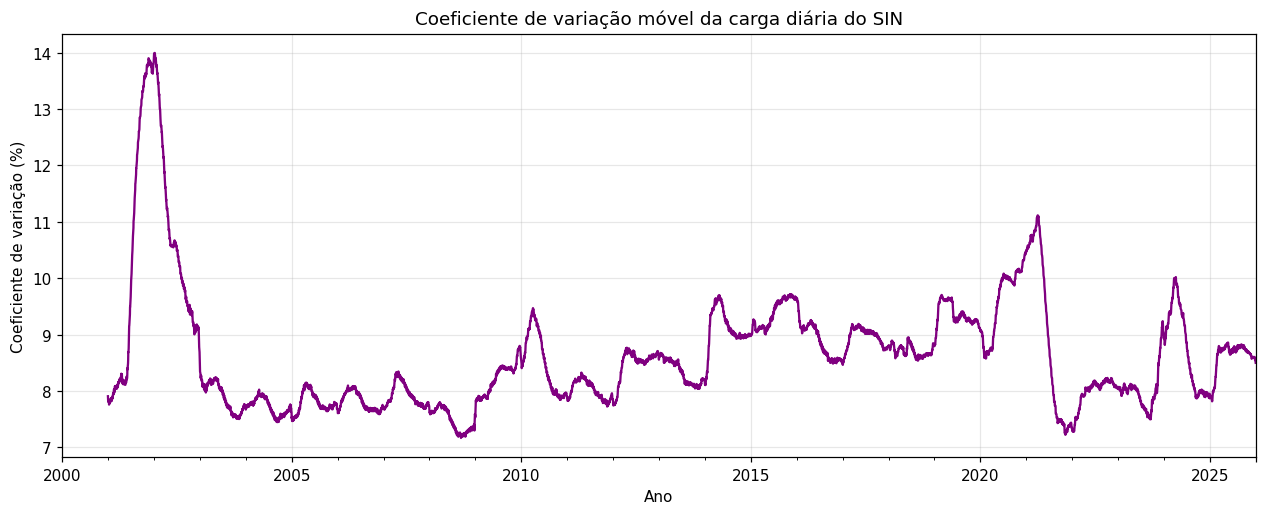

In [17]:
rolling_statistics['cv_%'].plot(
    figsize=(14, 5),
    color='purple'
)

plt.title('Coeficiente de variação móvel da carga diária do SIN')
plt.xlabel('Ano')
plt.ylabel('Coeficiente de variação (%)')
plt.grid(alpha=0.3)
plt.show()

In [18]:
cv = rolling_statistics['cv_%'].dropna()

print(cv.describe().round(2))
print()
print(f'Menor coeficiente: {cv.min():.2f}% em {cv.idxmin().date()}')
print(f'Maior coeficiente: {cv.max():.2f}% em {cv.idxmax().date()}')

count    9133.00
mean        8.63
std         1.08
min         7.17
25%         7.91
50%         8.42
75%         9.08
max        13.99
Name: cv_%, dtype: float64

Menor coeficiente: 7.17% em 2008-09-08
Maior coeficiente: 13.99% em 2002-01-06


O coeficiente de variação móvel apresentou média de 8,63%. Durante as janelas analisadas, ele ficou entre 7,17% e 13,99%.

Isso mostra que a dispersão em MWmed aumentou junto com o nível da carga, mas a variação proporcional permaneceu em uma faixa menor.

O maior valor aparece na janela que inclui 2001, ano que também apresentou a maior queda anual na análise exploratória.

Como a média e a variação não ficaram estáveis, o próximo passo será separar os componentes temporais da série.

## 5. Decomposição da Série Temporal

A série diária pode possuir mais de um ciclo. Neste caso, vamos analisar:

- 7 dias, representando o ciclo semanal;
- 365 dias, representando uma aproximação do ciclo anual.

Será utilizada a decomposição MSTL, que permite separar mais de uma sazonalidade. A opção robusta será utilizada para reduzir a influência de dias muito diferentes dos demais.


In [19]:
decomposition = MSTL(
    daily_series,
    periods=(7, 365),
    stl_kwargs={'robust': True}
).fit()

decomposition.seasonal.head()

,seasonal_7,seasonal_365
din_instante,,
2000-01-01,-1916.123242,-6996.203393
2000-01-02,-5769.446435,-12262.259574
2000-01-03,1227.842136,-3492.047484
2000-01-04,1829.628272,-1937.489462
2000-01-05,1683.233579,-727.501857


O resultado criou dois componentes sazonais: seasonal_7 e seasonal_365.

Isso mostra que o procedimento separou os ciclos semanal e anual que foram informados.

Primeiro, vamos comparar a carga observada com a tendência estimada para todo o período.


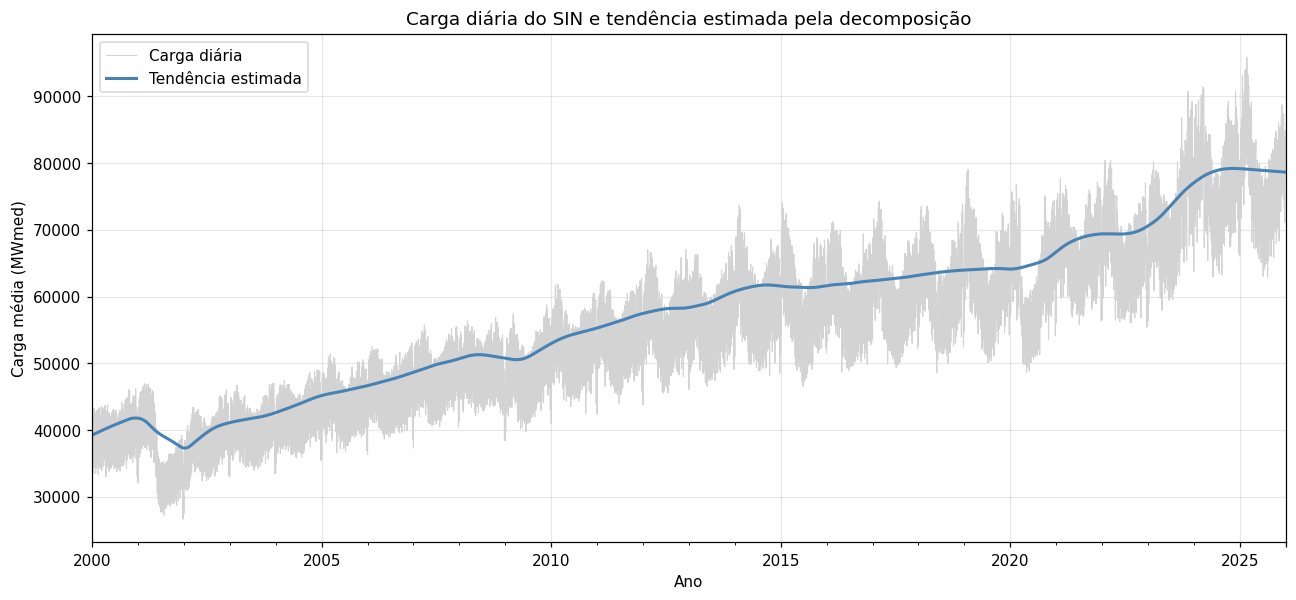

In [20]:
plt.figure(figsize=(14, 6))

daily_series.plot(
    color='lightgray',
    linewidth=0.7,
    label='Carga diária'
)
decomposition.trend.plot(
    color='steelblue',
    linewidth=2,
    label='Tendência estimada'
)

plt.title('Carga diária do SIN e tendência estimada pela decomposição')
plt.xlabel('Ano')
plt.ylabel('Carga média (MWmed)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
component_summary = decomposition.seasonal.agg(
    ['min', 'max', 'std']
).T

component_summary['amplitude'] = (
    component_summary['max']
    - component_summary['min']
)

component_summary.round(2)

,min,max,std,amplitude
seasonal_7,-11398.74,4695.59,3744.24,16094.33
seasonal_365,-12262.26,9357.34,2576.34,21619.60


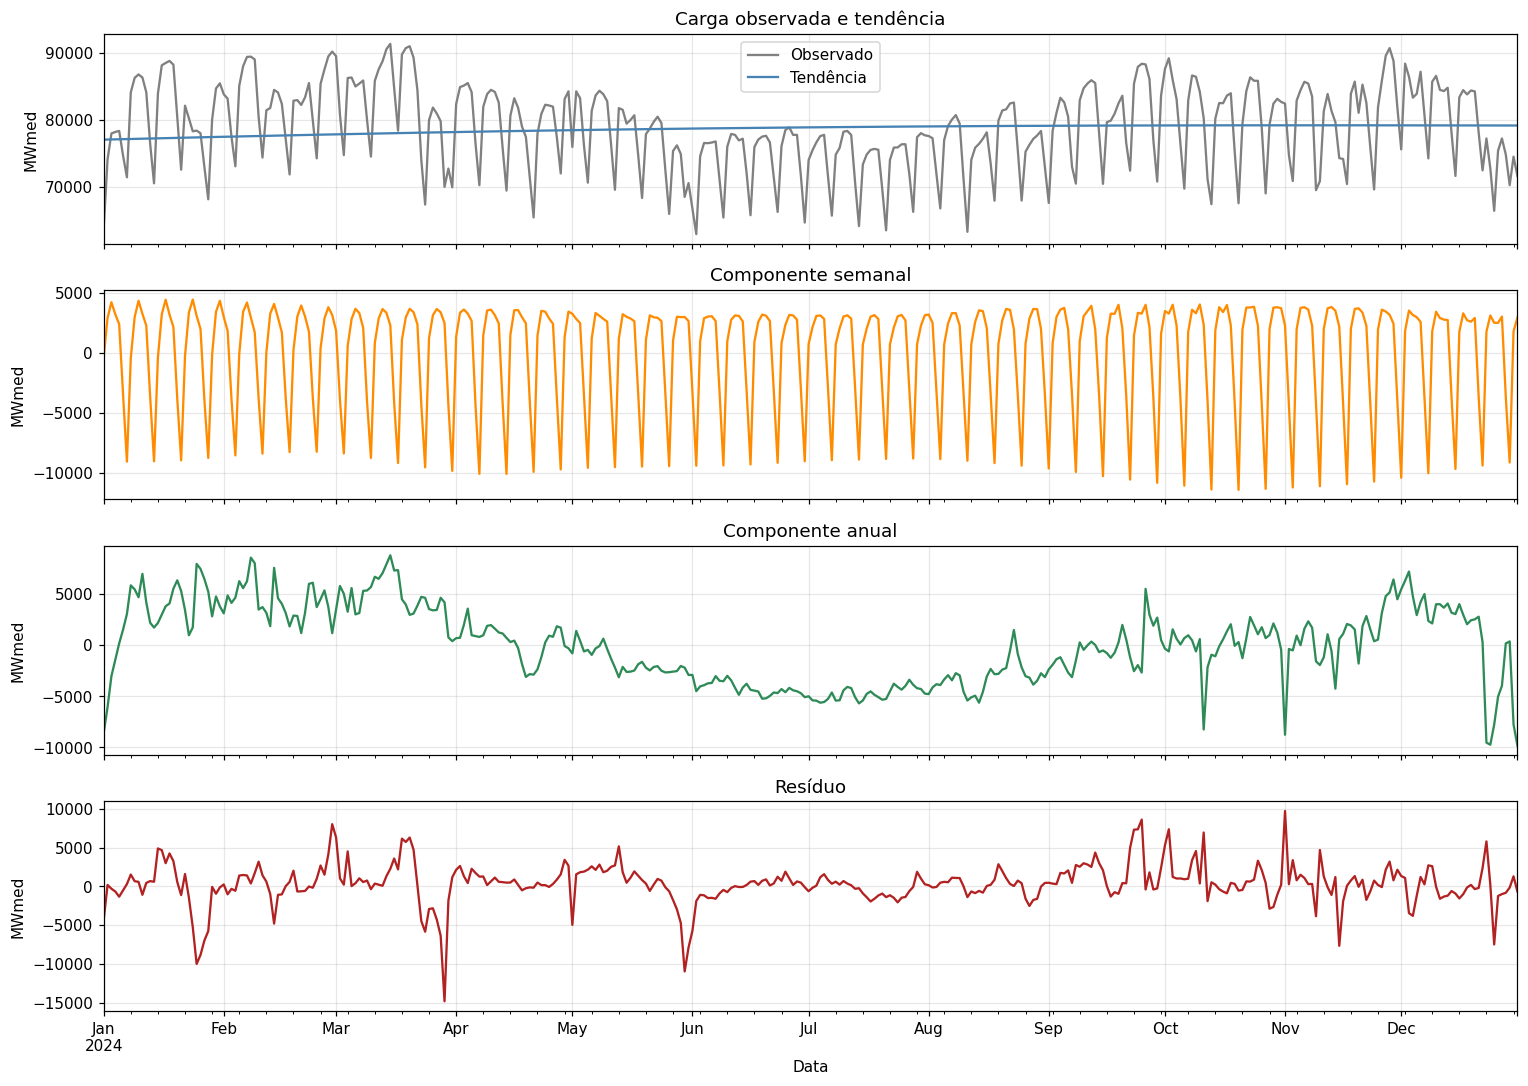

In [22]:
analysis_year = '2024'

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

daily_series.loc[analysis_year].plot(
    ax=axes[0],
    color='gray',
    label='Observado'
)
decomposition.trend.loc[analysis_year].plot(
    ax=axes[0],
    color='steelblue',
    label='Tendência'
)
axes[0].set_title('Carga observada e tendência')
axes[0].set_ylabel('MWmed')
axes[0].legend()

decomposition.seasonal.loc[
    analysis_year, 'seasonal_7'
].plot(ax=axes[1], color='darkorange')
axes[1].set_title('Componente semanal')
axes[1].set_ylabel('MWmed')

decomposition.seasonal.loc[
    analysis_year, 'seasonal_365'
].plot(ax=axes[2], color='seagreen')
axes[2].set_title('Componente anual')
axes[2].set_ylabel('MWmed')

decomposition.resid.loc[analysis_year].plot(
    ax=axes[3],
    color='firebrick'
)
axes[3].set_title('Resíduo')
axes[3].set_xlabel('Data')
axes[3].set_ylabel('MWmed')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

A tendência acompanha o crescimento de longo prazo e os períodos de redução ou estabilidade que já apareceram na série.

No início e no fim, a linha deve ser observada com mais cuidado, pois o método possui menos dados ao redor desses pontos para fazer a suavização.

O componente semanal apresentou uma amplitude de aproximadamente 16.094 MWmed. O componente anual chegou a aproximadamente 21.620 MWmed.

No recorte de 2024, o componente semanal repete movimentos curtos, enquanto o componente anual muda de forma mais lenta.

Os resíduos ainda possuem oscilações visíveis. Portanto, a tendência e os dois ciclos não explicaram tudo o que aconteceu na carga diária.

## 6. Autocorrelação

A autocorrelação mostra o quanto a série está relacionada com seus próprios valores anteriores.

Vamos observar até 60 dias de atraso. Também será calculada a primeira diferença, que representa a mudança entre um dia e o dia anterior.


In [23]:
first_difference = daily_series.diff().dropna()

selected_lags = [1, 2, 7, 14, 21, 28, 30]

autocorrelation_table = pd.DataFrame({
    'serie_original': [
        daily_series.autocorr(lag)
        for lag in selected_lags
    ],
    'primeira_diferenca': [
        first_difference.autocorr(lag)
        for lag in selected_lags
    ]
}, index=selected_lags)

autocorrelation_table.index.name = 'defasagem_dias'

autocorrelation_table.round(3)

,serie_original,primeira_diferenca
defasagem_dias,,
1,0.932,-0.054
2,0.872,-0.321
7,0.972,0.868
14,0.963,0.846
21,0.961,0.858
28,0.955,0.846
30,0.844,-0.297


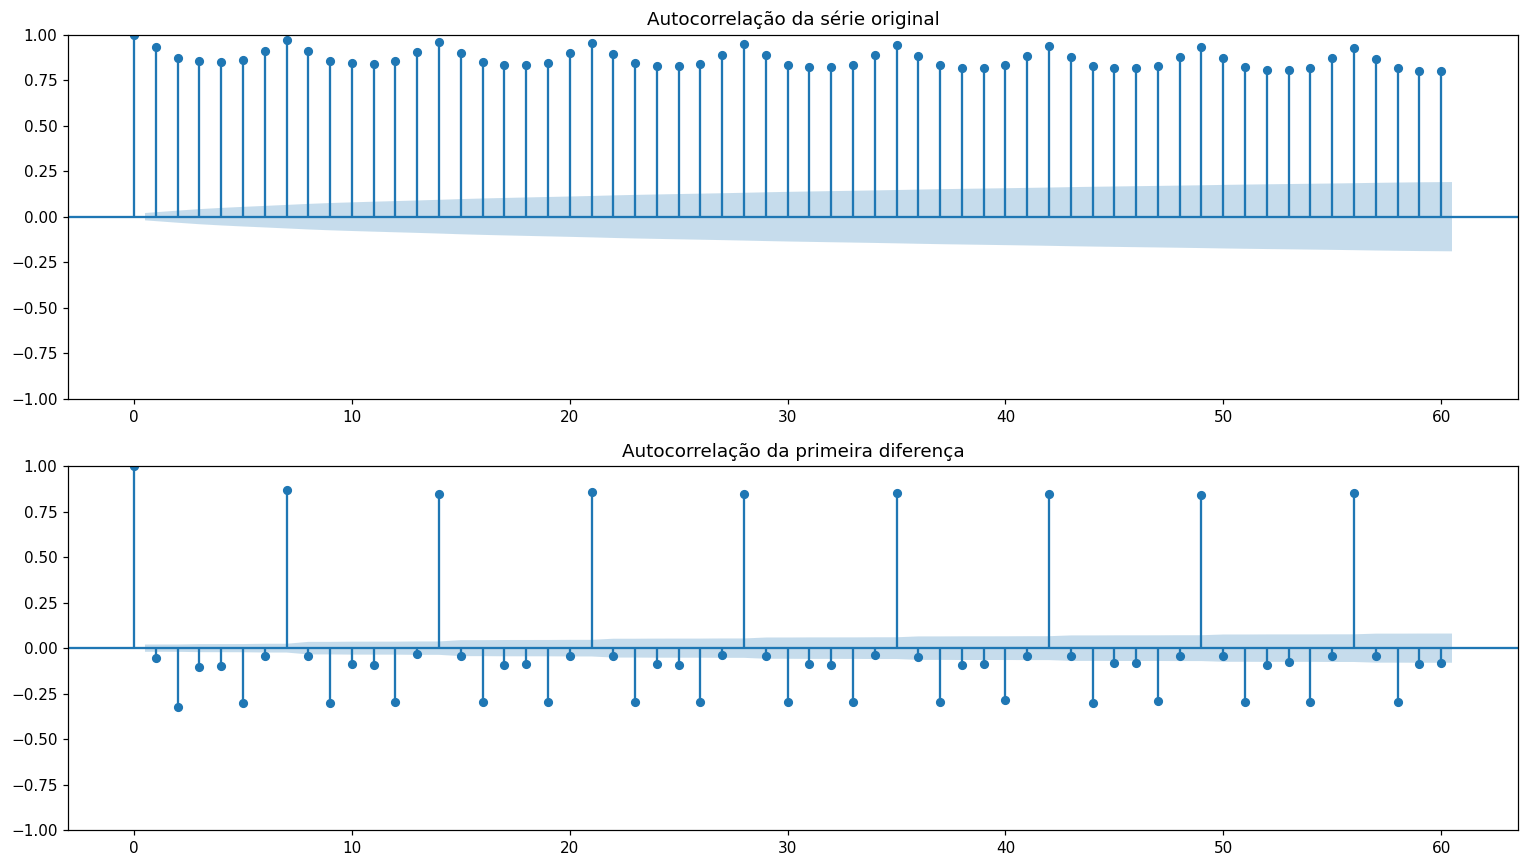

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(
    daily_series,
    lags=60,
    ax=axes[0],
    title='Autocorrelação da série original'
)

plot_acf(
    first_difference,
    lags=60,
    ax=axes[1],
    title='Autocorrelação da primeira diferença'
)

plt.tight_layout()
plt.show()

Na série original, várias correlações continuam altas. A correlação com o dia anterior foi de 0,932 e, com sete dias de diferença, chegou a 0,972.

Depois da primeira diferença, as correlações menores diminuíram. Mesmo assim, a defasagem de sete dias permaneceu alta, com 0,868. O mesmo formato aparece em 14, 21 e 28 dias.

Isso mostra que a tendência explica parte da relação entre os valores, mas o ciclo semanal continua presente nas mudanças diárias.

## 7. Testes de Estacionariedade

Os gráficos mostraram mudanças na média e na variação. Agora, vamos verificar esse comportamento com dois testes:

- ADF: parte da ideia de que a série não é estacionária;
- KPSS: parte da ideia de que a série é estacionária.

Será utilizado um nível de significância de 5%. Os testes serão aplicados na série original e na primeira diferença.


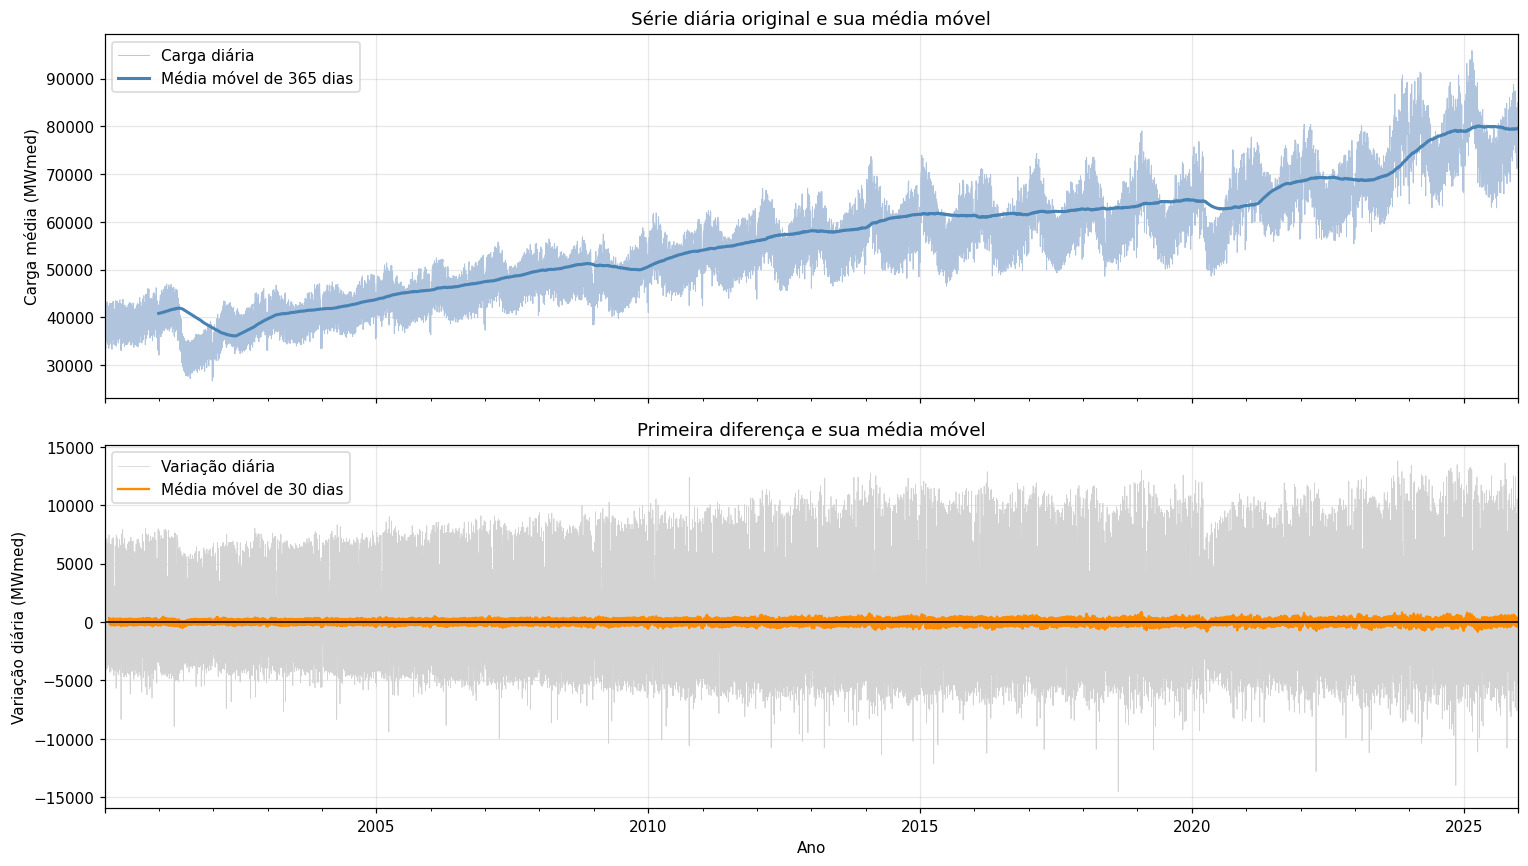

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

daily_series.plot(
    ax=axes[0],
    color='lightsteelblue',
    linewidth=0.6,
    label='Carga diária'
)
daily_series.rolling(365).mean().plot(
    ax=axes[0],
    color='steelblue',
    linewidth=2,
    label='Média móvel de 365 dias'
)
axes[0].set_title('Série diária original e sua média móvel')
axes[0].set_ylabel('Carga média (MWmed)')
axes[0].legend()
axes[0].grid(alpha=0.3)

first_difference.plot(
    ax=axes[1],
    color='lightgray',
    linewidth=0.5,
    label='Variação diária'
)
first_difference.rolling(30).mean().plot(
    ax=axes[1],
    color='darkorange',
    linewidth=1.5,
    label='Média móvel de 30 dias'
)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Primeira diferença e sua média móvel')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Variação diária (MWmed)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

A média móvel da série original muda de nível ao longo do tempo.

Na primeira diferença, a média oscila ao redor de zero e não apresenta a mesma tendência de crescimento.

Essa primeira observação é apenas visual. Agora, vamos executar os testes ADF e KPSS para comparar os resultados.


In [26]:
def stationarity_tests(series):

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        warnings.simplefilter('ignore', InterpolationWarning)

        adf_result = adfuller(series, autolag='AIC')
        kpss_result = kpss(series, regression='c', nlags='auto')

    return pd.Series({
        'estatistica_adf': adf_result[0],
        'p_valor_adf': adf_result[1],
        'estatistica_kpss': kpss_result[0],
        'p_valor_kpss': kpss_result[1]
    })


stationarity_results = pd.DataFrame({
    'serie_original': stationarity_tests(daily_series),
    'primeira_diferenca': stationarity_tests(first_difference)
}).T

stationarity_results.round(4)

,estatistica_adf,p_valor_adf,estatistica_kpss,p_valor_kpss
serie_original,-1.4486,0.5588,14.7509,0.01
primeira_diferenca,-20.9664,0.0000,0.0084,0.10


Na série original, o teste ADF apresentou p-valor de 0,5588. Como esse resultado é maior que 5%, não rejeitamos a ideia de que a série possui raiz unitária.

O KPSS apresentou p-valor de 0,01. Como ficou abaixo de 5%, rejeitamos a hipótese de estacionariedade.

Portanto, os dois testes indicam que a série original não é estacionária.

Na primeira diferença, o resultado muda. O ADF apresentou p-valor menor que 0,0001 e o KPSS apresentou 0,10. Nesse caso, os dois testes passam a indicar estacionariedade.

Os valores 0,01 e 0,10 do KPSS são os limites mostrados pela tabela utilizada pelo Statsmodels. Eles não representam resultados exatos além desses pontos.

## 8. Diagnóstico dos Resíduos da Decomposição

O resíduo representa a parte da série que não foi explicada pela tendência nem pelos ciclos semanal e anual.

Primeiro, vamos observar suas medidas estatísticas e sua distribuição. Depois, serão localizados os maiores desvios e verificada a autocorrelação que ainda permaneceu.


In [27]:
residuals = decomposition.resid

residual_summary = residuals.describe()
residual_summary.loc['assimetria'] = residuals.skew()
residual_summary.loc['curtose'] = residuals.kurt()

residual_summary.round(2)

count          9497.00
mean           -208.14
std            2262.54
min          -16950.29
25%            -883.92
50%              -1.74
75%             777.81
max           13486.50
assimetria       -0.90
curtose           6.80
Name: resid, dtype: float64

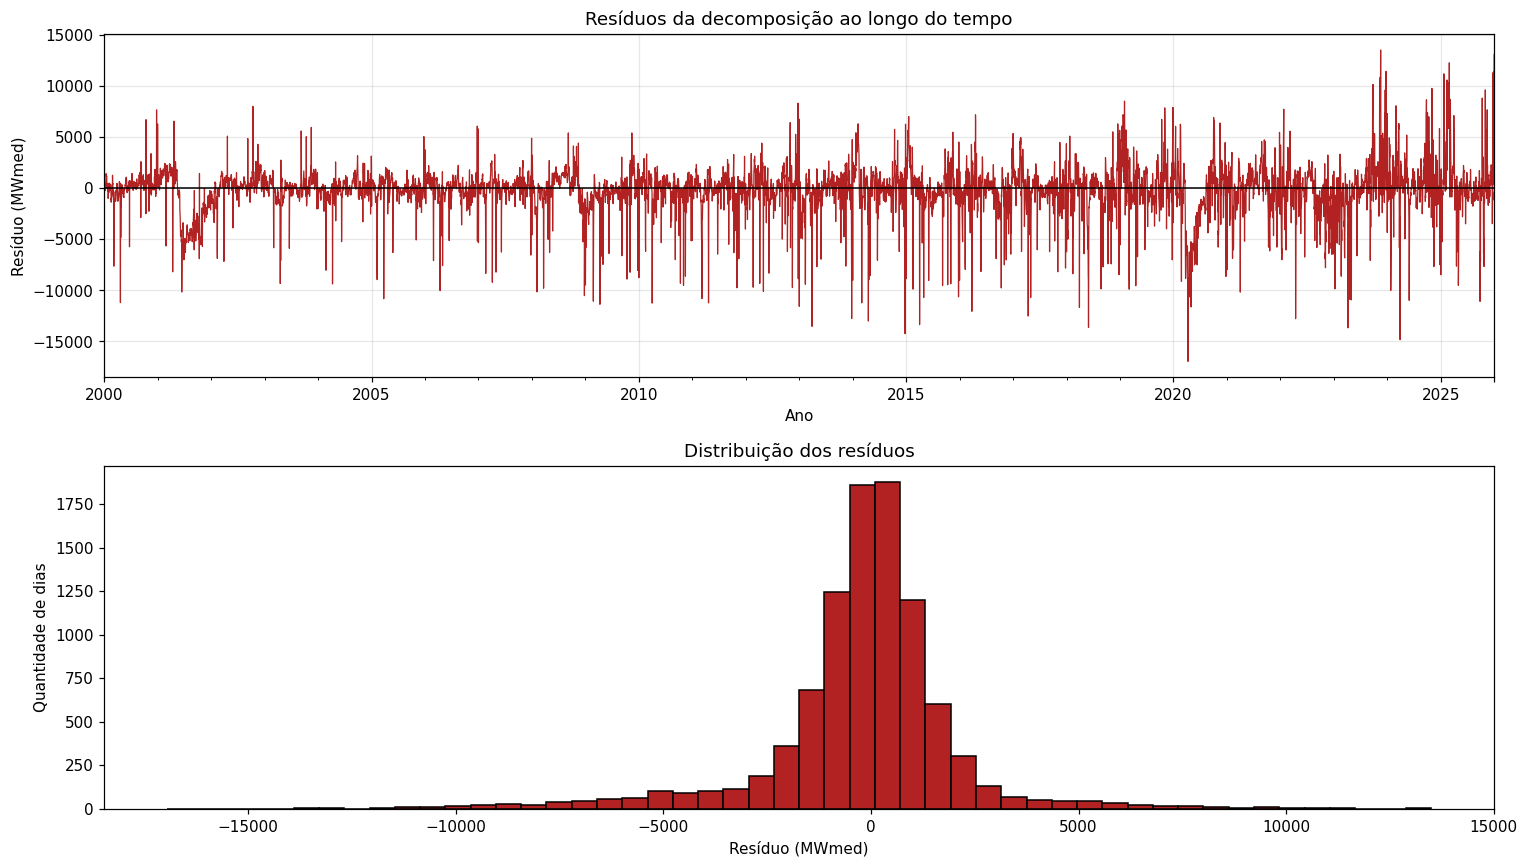

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

residuals.plot(
    ax=axes[0],
    color='firebrick',
    linewidth=0.8
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Resíduos da decomposição ao longo do tempo')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Resíduo (MWmed)')
axes[0].grid(alpha=0.3)

residuals.plot.hist(
    ax=axes[1],
    bins=50,
    color='firebrick',
    edgecolor='black'
)
axes[1].set_title('Distribuição dos resíduos')
axes[1].set_xlabel('Resíduo (MWmed)')
axes[1].set_ylabel('Quantidade de dias')

plt.tight_layout()
plt.show()

A mediana dos resíduos ficou próxima de zero, enquanto a média foi de aproximadamente -208 MWmed.

A assimetria foi de -0,90, mostrando uma cauda maior para os valores negativos. A curtose foi de 6,80, indicando uma presença maior de valores extremos do que seria esperado em uma distribuição normal.

O gráfico também mostra alguns períodos com desvios mais fortes. Agora, vamos listar os 15 maiores resíduos em valor absoluto para identificar suas datas.


In [29]:
largest_residuals = residuals.abs().nlargest(15).index

residual_extremes = pd.DataFrame({
    'residuo': residuals.loc[largest_residuals],
    'valor_absoluto': residuals.loc[largest_residuals].abs(),
    'dia_semana': largest_residuals.day_name()
}).sort_values('valor_absoluto', ascending=False)

residual_extremes.round(2)

,residuo,valor_absoluto,dia_semana
din_instante,,,
2020-04-10,-16950.29,16950.29,Friday
2024-03-29,-14834.98,14834.98,Friday
2014-12-25,-14246.97,14246.97,Thursday
2023-04-07,-13673.00,13673.00,Friday
2018-05-31,-13636.46,13636.46,Thursday
2013-03-29,-13529.16,13529.16,Friday
2023-11-17,13486.50,13486.50,Friday
2015-04-03,-13356.70,13356.70,Friday
2025-12-31,13046.57,13046.57,Wednesday


O maior resíduo aconteceu em 10/04/2020. O valor foi negativo e ficou próximo de 16.950 MWmed.

Entre os maiores resíduos negativos também aparecem o dia 25 de dezembro e várias sextas-feiras entre março e abril.

O resultado não explica a causa desses desvios. Ele apenas mostra que existem datas com comportamentos que não foram representados pelos ciclos semanal e anual.

Para entender melhor esses pontos, seria necessário comparar as datas com feriados e acontecimentos externos. Neste notebook, elas serão apenas registradas como casos que merecem atenção.

Por fim, vamos verificar se os resíduos ainda possuem relação com os dias anteriores.


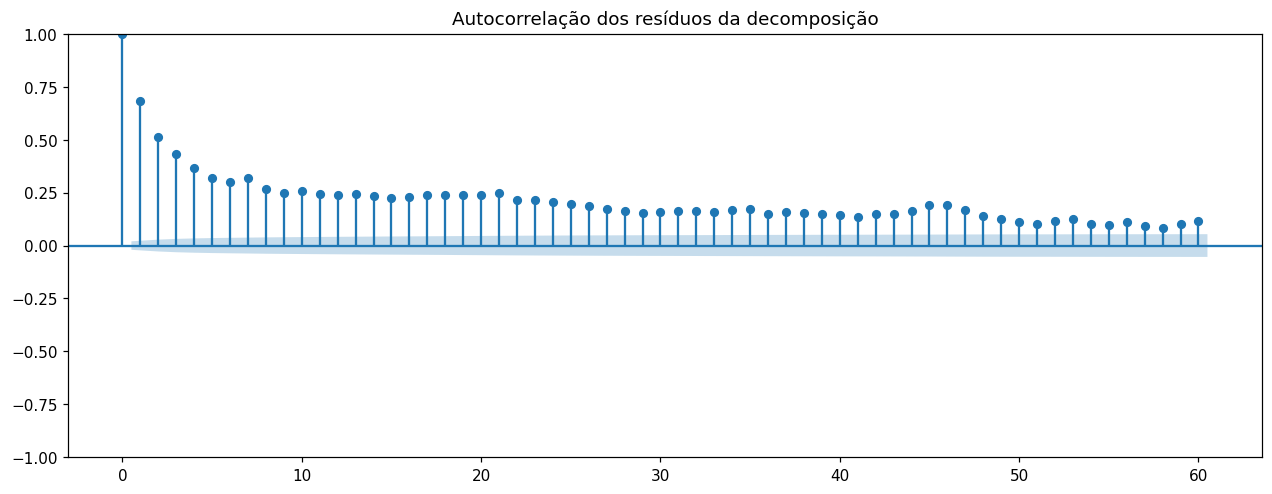

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    residuals,
    lags=60,
    ax=ax,
    title='Autocorrelação dos resíduos da decomposição'
)

plt.show()

In [31]:
residual_lags = [1, 2, 3, 7, 14, 21, 30]

residual_autocorrelation = pd.Series({
    lag: residuals.autocorr(lag)
    for lag in residual_lags
}, name='autocorrelacao')

residual_autocorrelation.index.name = 'defasagem_dias'

residual_autocorrelation.round(3)

defasagem_dias
1     0.685
2     0.514
3     0.436
7     0.323
14    0.234
21    0.250
30    0.160
Name: autocorrelacao, dtype: float64

A correlação dos resíduos com o dia anterior foi de 0,685. Na defasagem de sete dias, o valor ficou em 0,323.

Como ainda existem correlações visíveis, vamos aplicar o teste de Ljung–Box nas defasagens 7 e 30.

Nesse teste, a hipótese inicial considera que não existe autocorrelação até a defasagem analisada.


In [32]:
ljung_box_result = acorr_ljungbox(
    residuals,
    lags=[7, 30],
    return_df=True
)

ljung_box_result.index.name = 'defasagem_dias'

ljung_box_result.round(4)

,lb_stat,lb_pvalue
defasagem_dias,,
7,12795.5948,0.0
30,23612.4923,0.0


Nos dois limites analisados, o p-valor ficou abaixo de 0,0001.

Com isso, rejeitamos a hipótese de que os resíduos não possuem autocorrelação.

A decomposição retirou a tendência e ciclos importantes, mas os resíduos ainda não formam uma sequência completamente aleatória. Continua existindo uma relação entre dias próximos e uma parte menor do ciclo semanal.

## 9. Conclusão do Diagnóstico Temporal

As verificações mostraram os seguintes resultados:

- a série diária possui 9.497 dias;
- três dias sem carga foram preenchidos pela média do mesmo dia da semana anterior e posterior;
- os 19 dias com 23 horas foram mantidos sem alteração;
- a média e o desvio-padrão móveis mudam ao longo do tempo;
- a correlação entre essas duas medidas foi de 0,880;
- a decomposição separou tendência, ciclo semanal e ciclo anual;
- a autocorrelação continua alta nos múltiplos de sete dias;
- a série original não é estacionária;
- a primeira diferença foi classificada como estacionária pelos testes ADF e KPSS;
- os resíduos ainda possuem valores extremos e autocorrelação.

### Limitações

- os três valores preenchidos são estimativas;
- o período de 365 dias é uma aproximação do ciclo anual;
- a decomposição não utiliza feriados, clima, atividade econômica ou acontecimentos operacionais;
- mudanças na abrangência e na metodologia ainda afetam a comparação histórica;
- o diagnóstico foi feito para a carga diária do SIN e não substitui uma análise individual dos subsistemas.

Com essa etapa, finalizamos a análise estatística da série temporal. O projeto permanece descritivo e não utiliza previsão ou Machine Learning.
